# Reprojection

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on reprojecting a raster object.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [2]:
import numpy as np

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show

import rioxarray

import odc.geo.xr
from odc.geo.xr import xr_reproject

import geoutils as gu

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import dask

In [2]:
#path to the raster object
raster_path = "../data/PlanetObserver_PlanetSAT_10m_Ukraine_Odessa_UTM36.tif"

## Reprojection (without RPCs)

Reprojecting a raster feature is available in every library considered in this study.

It consists of converting a raster to a different coordinate reference system (CRS) to be correctly aligned with other data.

### • rasterio

In [3]:
ds_rasterio = rasterio.open(raster_path)

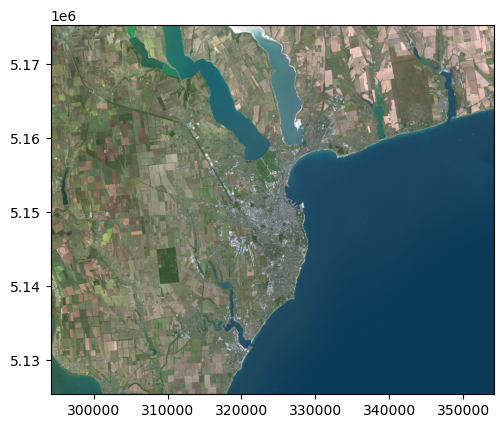

<Axes: >

In [4]:
show(ds_rasterio)

In [6]:
print(f"Dataset's CRS : {ds_rasterio.crs}")

Dataset's CRS : EPSG:32636


Our raster is currently projected in EPSG:32636, and we want to convert it to EPSG:4326.

We will use the *calculate_default_transform()* function to transform bounds to target coordinate system, calculate resolution, and returns destination transform and dimensions.

We will then use *reproject()* to reproject our raster to the new CRS :

In [7]:
dst_crs = "EPSG:4326" #target CRS

dst_path = "../outputs/rasterio_reproj.tif"

with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy() #copy metadatas
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

One thing to mention here, is that we need to copy all metadatas of the input raster and reuse them to reproject our new raster, which is not really convenient.

We can then plot our new image and its CRS :

EPSG:4326


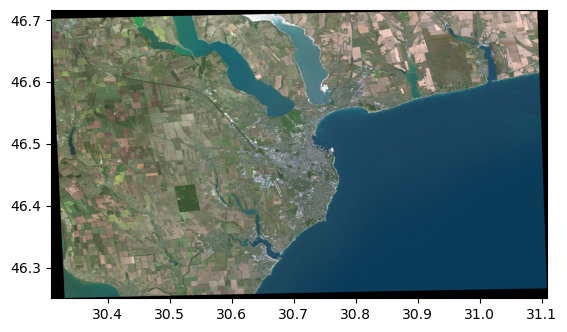

In [8]:
with rasterio.open(dst_path) as rasterio_reproj:
    print(rasterio_reproj.crs)
    show(rasterio_reproj)

### • rioxarray

With rioxarray, we will use the *.reproject()* function : https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject

In [9]:
da_rxr = rioxarray.open_rasterio(raster_path)

In [11]:
print(f"Array's CRS : {da_rxr.rio.crs}")

Array's CRS : EPSG:32636


The *.reproject()* function is more "straight-forward" than in rasterio, we just need to specify the targeted CRS :

In [12]:
rxr_reproj = da_rxr.rio.reproject(dst_crs)

We can verify the new CRS and image :

In [14]:
print(f"CRS : {rxr_reproj.rio.crs}")

CRS : EPSG:4326


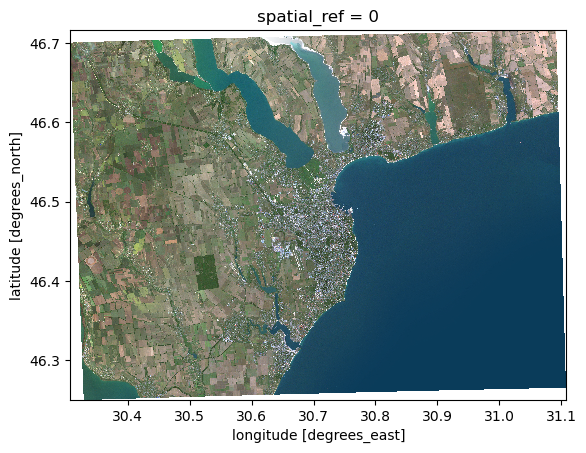

In [15]:
rxr_reproj.plot.imshow()

### • odc-geo

With odc-geo, we will use the *.reproject()* function to reproject our raster : https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.xr_reproject.html

In [3]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

We can simply pass the image and the desired CRS as arguments :

In [5]:
dst_crs = "EPSG:4326"

In [6]:
odcgeo_reproj = xr_reproject(ds_odcgeo, dst_crs)

In [7]:
print(odcgeo_reproj.rio.crs)

EPSG:4326


Let's plot the newly created raster :

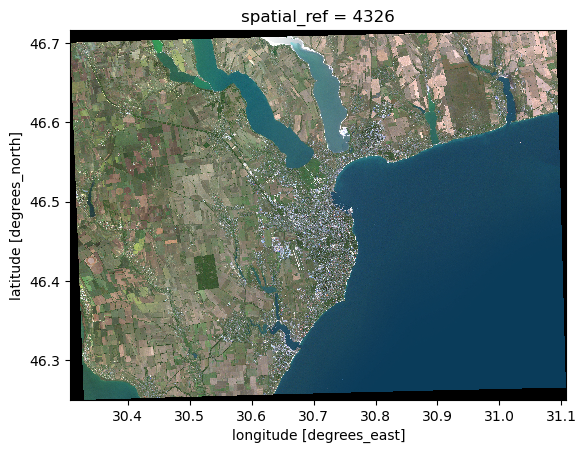

In [8]:
odcgeo_reproj.plot.imshow()

### • geoutils

In geoutils, we will use the *.reproject()* function : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html#geoutils.Raster.reproject

In [9]:
ds_geoutils = gu.Raster(raster_path)

In [13]:
print(f"Dataset's CRS : {ds_geoutils.crs}")

Dataset's CRS : EPSG:32636


To reproject, we can simply pass the targeted CRS as an argument :

In [14]:
gu_reprojected = ds_geoutils.reproject(crs=dst_crs)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\os_rasters_comp\Lib\site-packages\geoutils\raster\_geotransformations.py:117: UserWarning: For reprojection, nodata must be set. Setting default nodata to 255. You may set a different nodata with `nodata`.
  warnings.warn(


In [17]:
print(f"Reprojected Dataset's CRS : {gu_reprojected.crs}")

Reprojected Dataset's CRS : EPSG:4326


We can finally plot the new raster :

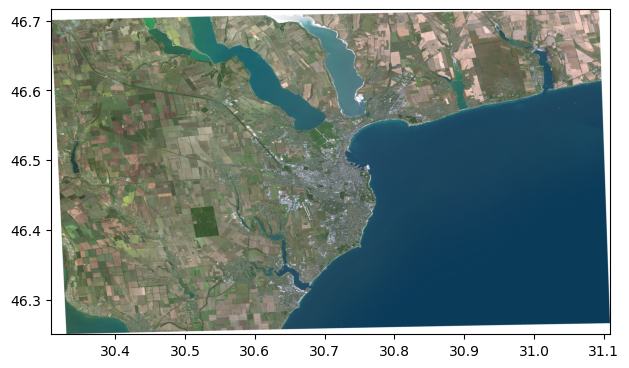

In [18]:
gu_reprojected.plot()

## Reprojection (with RPCs - Rational Polynomial Coefficients)

Reprojecting with RPCs is only implemented in rasterio and rioxarray, not in odc-geo or geoutils.

### • rasterio

https://rasterio.readthedocs.io/en/stable/topics/reproject.html#reprojecting-with-other-georeferencing-metadata

### • rioxarray

==TO BE COMPLETED==

## Reproject match

Reproject match is a feature only available in rioxarray and geoutils.

This feature is useful to reproject an image to match the resolution, projection and region of another raster.

### • rioxarray

With rioxarray, we can use the *.reproject_match()* function : https://corteva.github.io/rioxarray/stable/examples/reproject_match.html

In this example we will try to reproject the wrong CRS of the small part of Sardinia with the correct one.

In [3]:
valid_raster_path = "../data/sard_1.tif"

invalid_raster_path = "../data/sard_2_wrong_crs.tif"

In [4]:
da_rxr_valid = rioxarray.open_rasterio(valid_raster_path)

da_rxr_invalid = rioxarray.open_rasterio(invalid_raster_path)

In [21]:
print(f"""
VALID RASTER ATTRIBUTES\n
shape: {da_rxr_valid.rio.shape}
resolution: {da_rxr_valid.rio.resolution()}
bounds: {da_rxr_valid.rio.bounds()}
CRS: {da_rxr_valid.rio.crs}
""")


VALID RASTER ATTRIBUTES

shape: (9835, 5761)
resolution: (25.0, -25.0)
bounds: (4162400.0, 1754125.0, 4306425.0, 2000000.0)
CRS: IGNF:ETRS89LAEA



In [22]:
print(f"""
INVALID RASTER ATTRIBUTES\n
shape: {da_rxr_invalid.rio.shape}
resolution: {da_rxr_invalid.rio.resolution()}
bounds: {da_rxr_invalid.rio.bounds()}
CRS: {da_rxr_invalid.rio.crs} <-- to be changed
""")


INVALID RASTER ATTRIBUTES

shape: (950, 4389)
resolution: (25.0, -25.0)
bounds: (4175200.0, 2000000.0, 4284925.0, 2023750.0)
CRS: IGNF:ETRS89UTM32 <-- to be changed



Here is the wrong CRS : *IGNF:ETRS89UTM32* and we want to change it to : *IGNF:ETRS89LAEA*

We can use the *reproject_match()* function, we just have to pass the raster correctly projected as an argument :

In [23]:
rxr_repr_match = da_rxr_invalid.rio.reproject_match(da_rxr_valid)

If we check the newly projected raster, its CRS has been changed accordingly to our referenced raster : 

In [24]:
print(f"""
REPROJECTED RASTER ATTRIBUTES\n
shape: {rxr_repr_match.rio.shape}
resolution: {rxr_repr_match.rio.resolution()}
bounds: {rxr_repr_match.rio.bounds()}
CRS: {rxr_repr_match.rio.crs}
""")


REPROJECTED RASTER ATTRIBUTES

shape: (9835, 5761)
resolution: (25.0, -25.0)
bounds: (4162400.0, 1754125.0, 4306425.0, 2000000.0)
CRS: IGNF:ETRS89LAEA



### • geoutils

To reproject match using geoutils, we will reuse the *.reproject()* function already seen previously, but this time we will pass the argument "ref=" with another raster, so our image will be reprojected according to the resolution, bounds and CRS of this referenced raster.

https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html

In [5]:
gu_rast_valid = gu.Raster(valid_raster_path)

gu_rast_invalid = gu.Raster(invalid_raster_path)

In [6]:
gu_rast_valid.info()

Driver:               GTiff 
Opened from file:     ../data/sard_1.tif 
Filename:             ../data/sard_1.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            5761, 9835
Number of bands:      1
Data types:           float32
Coordinate system:    ['IGNF:ETRS89LAEA']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           25.0, 25.0
Upper left corner:    4162400.0, 2000000.0
Lower right corner:   4306425.0, 1754125.0



In [7]:
gu_rast_invalid.info()

Driver:               GTiff 
Opened from file:     ../data/sard_2_wrong_crs.tif 
Filename:             ../data/sard_2_wrong_crs.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            4389, 950
Number of bands:      1
Data types:           float32
Coordinate system:    ['IGNF:ETRS89UTM32']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           25.0, 25.0
Upper left corner:    4175200.0, 2023750.0
Lower right corner:   4284925.0, 2000000.0



As previously, we can reuse the *reproject()* function, but this time we pass our valid raster as an argument :

In [8]:
gu_reproj = gu_rast_invalid.reproject(gu_rast_valid)

The reprojected raster has now the right CRS :

In [9]:
gu_reproj.info()

Driver:               None 
Opened from file:     None 
Filename:             None 
Loaded?               True 
Modified since load?  True 
Grid size:            5761, 9835
Number of bands:      1
Data types:           float32
Coordinate system:    ['IGNF:ETRS89LAEA']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           25.0, 25.0
Upper left corner:    4162400.0, 2000000.0
Lower right corner:   4306425.0, 1754125.0

